In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.isna().sum() * 100 / len(df)

customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['gender'].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

In [11]:
for col in df.columns:
    print(col, df[col].unique())
    print(" ")

customerID ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
 
gender ['Female' 'Male']
 
SeniorCitizen [0 1]
 
Partner ['Yes' 'No']
 
Dependents ['No' 'Yes']
 
tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
 
PhoneService ['No' 'Yes']
 
MultipleLines ['No phone service' 'No' 'Yes']
 
InternetService ['DSL' 'Fiber optic' 'No']
 
OnlineSecurity ['No' 'Yes' 'No internet service']
 
OnlineBackup ['Yes' 'No' 'No internet service']
 
DeviceProtection ['No' 'Yes' 'No internet service']
 
TechSupport ['No' 'Yes' 'No internet service']
 
StreamingTV ['No' 'Yes' 'No internet service']
 
StreamingMovies ['No' 'Yes' 'No internet service']
 
Contract ['Month-to-month' 'One year' 'Two year']
 
PaperlessBilling ['Yes' 'No']
 
PaymentMethod ['Electronic check' 'Mailed check' 'Bank tran

In [12]:
df['tenure'].max()

72

In [13]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [14]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Text(0, 0.5, '')

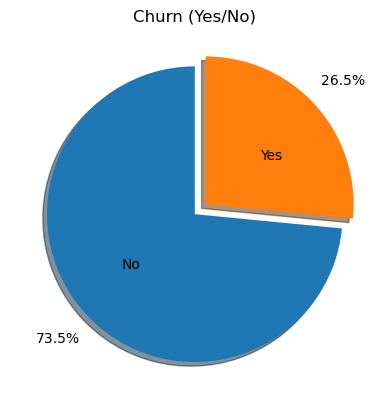

In [15]:
colors = sns.color_palette('pastel')
df['Churn'].value_counts().plot(kind='pie', startangle=90, autopct="%1.1f%%",
                                explode=(0, 0.1), shadow=True, pctdistance=1.25, labeldistance=0.50)
plt.title("Churn (Yes/No)")
plt.ylabel("")

In [16]:
df.groupby(['Churn', 'gender'])['MonthlyCharges'].mean()

Churn  gender
No     Female    61.664908
       Male      60.876914
Yes    Female    74.812087
       Male      74.066989
Name: MonthlyCharges, dtype: float64

In [17]:
df.groupby('Churn')['tenure'].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

In [18]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

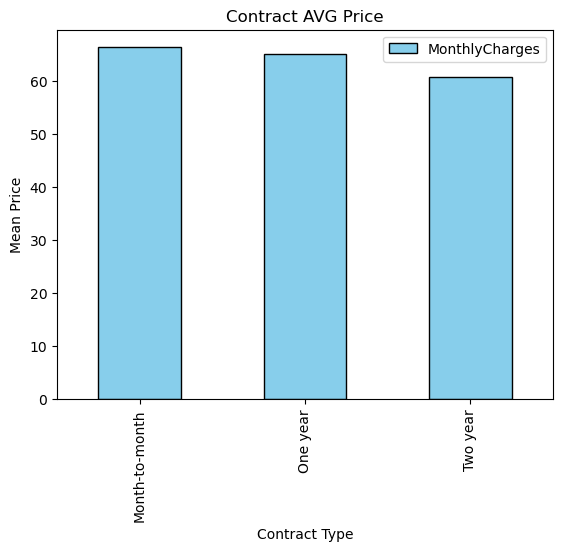

In [19]:
df.groupby('Contract')['MonthlyCharges'].mean().plot(kind='bar', color='skyblue', edgecolor='black', legend=True)
plt.xlabel("Contract Type")
plt.ylabel("Mean Price")
plt.title("Contract AVG Price")
plt.show

In [20]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

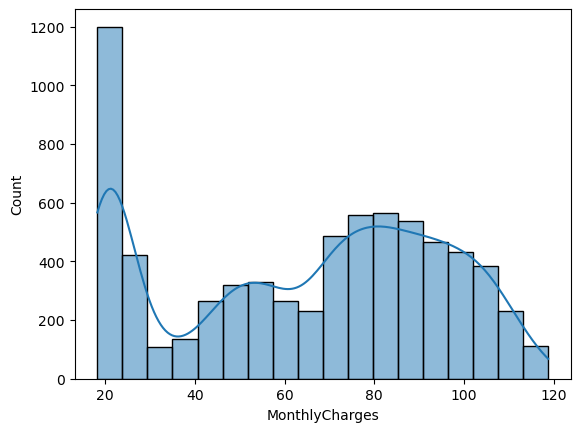

In [21]:
sns.histplot(df['MonthlyCharges'], kde=True)

<Axes: xlabel='tenure', ylabel='Count'>

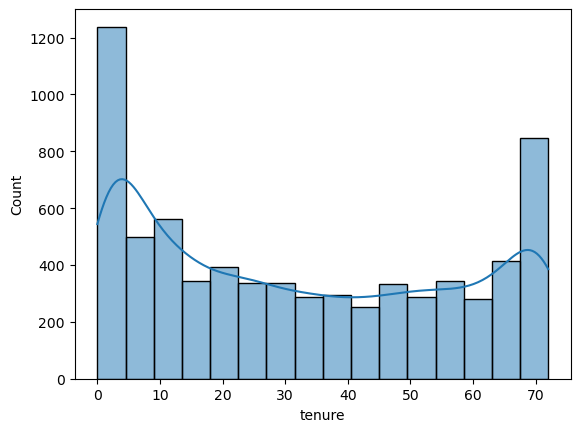

In [22]:
sns.histplot(df['tenure'], kde=True)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


<Axes: xlabel='Churn', ylabel='count'>

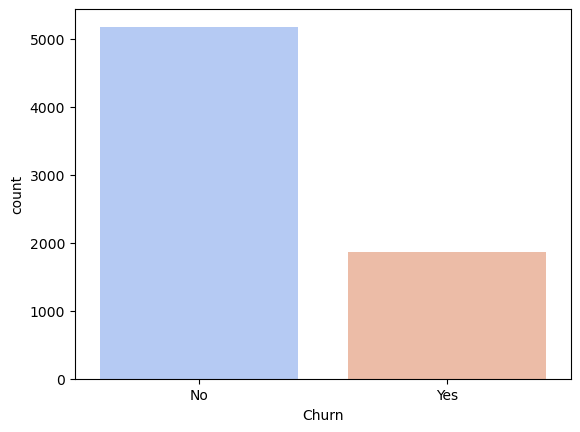

In [23]:
print(df['Churn'].value_counts())

sns.countplot(x=df['Churn'], palette='coolwarm')

<Axes: xlabel='Contract', ylabel='count'>

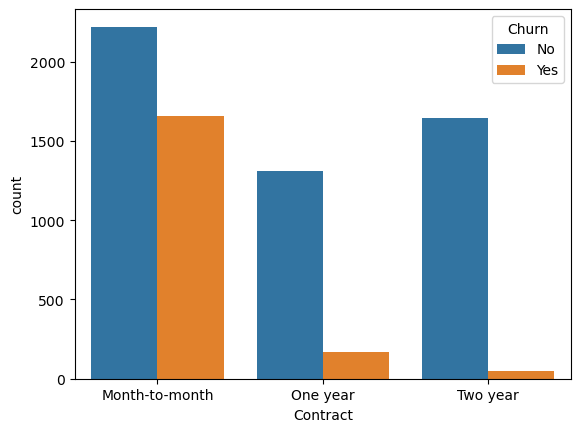

In [24]:
sns.countplot(x=df['Contract'], hue=df['Churn'])

<Axes: >

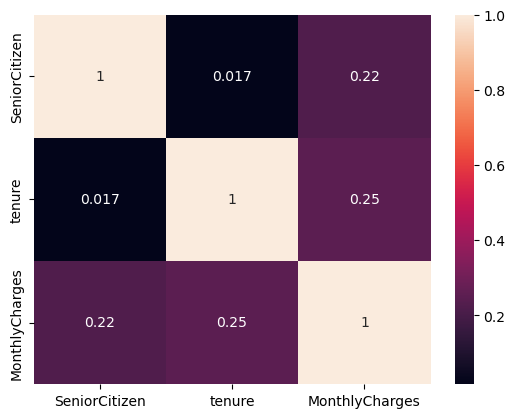

In [25]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [26]:
df['TotalCharges'].sample(5)

5352       2537
3657     861.85
5668    3949.15
3345    7323.15
6933       69.6
Name: TotalCharges, dtype: object

In [27]:
##### # Perform Lable encoder

from sklearn.preprocessing import LabelEncoder

labelencoder = LabelEncoder()

categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 
                    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 
                    'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

for col in categorical_cols:
    df[col] = labelencoder.fit_transform(df[col])

In [28]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.5,0
2,3668-QPYBK,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,151.65,1


In [29]:
# We dosen't need customerID so drop it

df.drop('customerID', axis=1, inplace=True)
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.5,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1990.5,0
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,7362.9,0
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,346.45,0
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,306.6,1


In [30]:
df.dtypes

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges         object
Churn                 int64
dtype: object

In [31]:
# replace empty string in Total Charges

df['TotalCharges'] = df['TotalCharges'].replace(' ', pd.NA)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mean())

In [32]:
df['TotalCharges'].dtype

dtype('float64')

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [34]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,-1.277445,0,1,0,0,2,0,0,0,0,0,1,2,-1.160323,-0.994971,0
1,1,0,0,0,0.066327,1,0,0,2,0,2,0,0,0,1,0,3,-0.259629,-0.173876,0
2,1,0,0,0,-1.236724,1,0,0,2,2,0,0,0,0,0,1,3,-0.362660,-0.960399,1


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   float64
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   int64  
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   int64  


In [36]:
# Train Test split data

from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Perform feature scalling

In [37]:
x_train_scale = scaler.fit_transform(X_train)
x_test_scale = scaler.transform(X_test)

## Model Selection

In [38]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression()
model_lr.fit(x_train_scale, y_train)

LogisticRegression()

In [39]:
y_pred_lr = model_lr.predict(x_test_scale)

In [40]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

confusion_matrix(y_test, y_pred_lr)

array([[933, 103],
       [156, 217]])

In [41]:
accuracy_score(y_test, y_pred_lr)

0.8161816891412349

In [42]:
f1_score(y_test, y_pred_lr)

0.6262626262626263

In [43]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



## Check all model with his scoring

In [44]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

In [45]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier()
}

In [46]:
result = []

for name, model in models.items():
    model.fit(x_train_scale, y_train)
    y_pred = model.predict(x_test_scale)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # print model with his name and scoring
    result.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "F1 Score": round(f1, 4)
    })

In [47]:
result

[{'Model': 'Logistic Regression', 'Accuracy': 0.8162, 'F1 Score': 0.6263},
 {'Model': 'KNN', 'Accuracy': 0.775, 'F1 Score': 0.5554},
 {'Model': 'Decision Tree', 'Accuracy': 0.7289, 'F1 Score': 0.4974},
 {'Model': 'SVM', 'Accuracy': 0.807, 'F1 Score': 0.5789},
 {'Model': 'Naive Bayes', 'Accuracy': 0.758, 'F1 Score': 0.6289},
 {'Model': 'Random Forest', 'Accuracy': 0.8013, 'F1 Score': 0.5611}]

## Model tuning 

In [48]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

### SVM Tuning

In [50]:
model_svm = SVC(degree=3, random_state=42)

svm_param = {
    'C': [1, 20, 25, 30],
    'kernel': ['rbf', 'linear'],
    'gamma':['auto', 'scale']
}

model_svm_tuning = RandomizedSearchCV(
    model_svm, param_distributions=svm_param, cv=5, return_train_score=False
)

In [51]:
model_svm_tuning.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=SVC(random_state=42),
                   param_distributions={'C': [1, 20, 25, 30],
                                        'gamma': ['auto', 'scale'],
                                        'kernel': ['rbf', 'linear']})

In [52]:
print("Best Param :", model_svm_tuning.best_params_)

Best Param : {'kernel': 'rbf', 'gamma': 'auto', 'C': 1}


In [54]:
y_pred_svm = model_svm_tuning.predict(X_test)

In [55]:
accuracy_score(y_test, y_pred_svm)

0.8126330731014905

In [56]:
f1_score(y_test, y_pred_svm)

0.5875

### Random Forest Tuning

In [58]:
param_dist = {
    'n_estimators': np.arange(50, 300, 50),
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

model_rf = RandomForestClassifier(class_weight='balanced')

model_rf_tuning = RandomizedSearchCV(
    model_rf, param_distributions=param_dist,
    n_iter=20, cv=5, scoring='f1', random_state=42, return_train_score=False
)

In [59]:
model_rf_tuning.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(class_weight='balanced'),
                   n_iter=20,
                   param_distributions={'max_depth': [None, 5, 10, 20],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': array([ 50, 100, 150, 200, 250])},
                   random_state=42, scoring='f1')

In [61]:
print("Best Params:", model_rf_tuning.best_params_)

Best Params: {'n_estimators': np.int64(200), 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 10}


In [62]:
y_pred_rf = model_rf_tuning.predict(X_test)

In [64]:
accuracy_score(y_test, y_pred_rf)

0.7835344215755855

In [65]:
f1_score(y_test, y_pred_rf)

0.6473988439306358